In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures


It seems Dataset 1 shows a linear relationship, while Dataset 2 appears to show a polynomial relationship.

MSE_1: 0.01802
R²_1:  0.99946
coef_1 : [2.0030303]
intercept_1 : 3.0563636363636384

MSE_2: 1.34130
R²_2:  0.98071
coef_2 : [-0.66048951  1.84818182]
intercept_2 : 4.295804195804205

degree 2 | adjusted R² = 0.9759
degree 5 | adjusted R² = 0.9789
degree 8 | adjusted R² = 0.9900
Degree 10: adjested R² = 0, float division by zero

Prediction for 4.5 hours 12.07
Prediction for 0.5 load_kg [4.05787879]


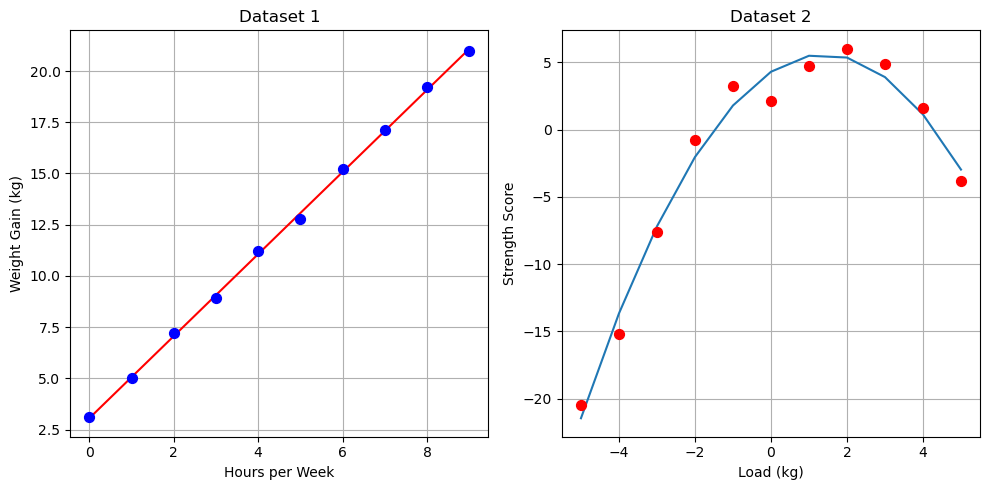

In [3]:
############################################################# Dataset 1 - gym hours vs muscle gain
# X: hours in gym per week. Y: muscle mass gain (kg).
# hours_week = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

hours_week = np.arange(0, 9 +1).reshape(-1, 1)
gain_kg = np.array([3.1, 5.0, 7.2, 8.9, 11.2, 12.8, 15.2, 17.1, 19.2, 21.0])


############################################################# Dataset 2 - load vs strength score
# X: daily weightlifting load (kg). Y: muscle strength score.

load_kg = np.arange(-5, 5 +1).reshape(-1, 1)
strength_score = np.array([-20.5, -15.2, -7.6, -0.8, 3.2, 2.1, 4.7, 6.0, 4.9, 1.6, -3.8])

############################################################# Question 1 - visual decision
# Plot the data (scatter plot) for each dataset and decide visually what kind of pattern it shows


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

# Dataset 1
axes[0].scatter(hours_week, gain_kg, color='blue', zorder = 5, s=50)
axes[0].set_title("Dataset 1")
axes[0].set_xlabel("Hours per Week")
axes[0].set_ylabel("Weight Gain (kg)")
axes[0].grid(True)

# Dataset 2
axes[1].scatter(load_kg, strength_score, color='red', zorder = 5, s=50)
axes[1].set_title("Dataset 2")
axes[1].set_xlabel("Load (kg)")
axes[1].set_ylabel("Strength Score")
axes[1].grid(True)

plt.tight_layout()
print('\nIt seems Dataset 1 shows a linear relationship, while Dataset 2 appears to show a polynomial relationship.\n')

############################################################# Question 2 - choose model type
# If the pattern looks linear, fit LinearRegression. If it looks curved, fit Polynomial Regression with degree 2
############################################################# Question 3 - metrics for both models
# For both models, calculate and print MSE and R²
model1 = LinearRegression()
model1.fit(hours_week, gain_kg)
y_pred = model1.predict(hours_week)
mse = mean_squared_error(gain_kg, y_pred)
R2_1 = r2_score(gain_kg, y_pred)
print(f"MSE_1: {mse:.5f}")
print(f"R²_1:  {R2_1:.5f}")
print(f"coef_1 : {model1.coef_}")
print(f"intercept_1 : {model1.intercept_}\n")
axes[0].plot(hours_week, y_pred, color='r')

feature_engine = PolynomialFeatures(degree=2, include_bias=True)
X_poly = feature_engine.fit_transform(load_kg)
model2 = LinearRegression()
model2.fit(X_poly, strength_score)
y_pred = model2.predict(X_poly)
mse = mean_squared_error(strength_score, y_pred)
R2_2 = r2_score(strength_score, y_pred)
print(f"MSE_2: {mse:.5f}")
print(f"R²_2:  {R2_2:.5f}")
print(f"coef_2 : {model2.coef_[::-1][0:2]}")
print(f"intercept_2 : {model2.intercept_}\n")
axes[1].plot(load_kg, y_pred)

############################################################# Question 4 - adjusted R² (polynomial only)
# For the polynomial regression model only, calculate and print Adjusted R² for degree=2, 5, 8, 10

for d in [2, 5, 8, 10]:
    feature_engine = PolynomialFeatures(degree= d, include_bias=True)
    X_poly = feature_engine.fit_transform(load_kg)
    model2 = LinearRegression()
    model2.fit(X_poly, strength_score)
    y_pred = model2.predict(X_poly)
    R2_2 = r2_score(strength_score, y_pred)
    n = len(strength_score)
    p = d
    top = (1 - R2_2) * (n - 1)
    bottom = n - p - 1
    try :
        adj_r2 = 1 - (top / bottom)
        print(f"degree {d} | adjusted R² = {adj_r2:.4f}")
    except ZeroDivisionError as e:
        print(f"Degree {d}: adjested R² = {0}, {e}\n")
    
############################################################# Question 5 - predictions
# Using model.predict, predict the value of 4.5 hours in the first model and 0.5 load-kg in the second model
pred_1 = model1.predict([[4.5]])
print(f'Prediction for 4.5 hours {pred_1[0]}')

pred_2 = model1.predict([[0.5]])
print(f'Prediction for 0.5 load_kg {pred_2}')
# from dmba import adjusted_r2_score
# adj_r2 = adjusted_r2_score(strength_score, y_pred, model) 
# print('adjusted R2 score', adj_r2)